# Keyword trend modeling 
Changes vs v1:
1. **Leak-free candidate selection**: rising words are selected using data only up to `SELECT_END` (before the test window), not the 2024-informed `rising_words_all_subjects.parquet`.
2. **Leak-free specificity**: computed cumulatively (counts up to year t only), not from all-years totals.
3. **Zero-filled panel**: years where a word does not appear count as share = 0 instead of being skipped by `shift()`.
4. **Target = change in share** (`dshare = share(t+1) - share(t)`), so metrics measure real skill instead of lag-1 autocorrelation.
5. **Sample weights** = title-word volume at t+1 (noisy small-subject years count less).
6. **Honest baselines**: zero-change (persistence) and momentum (`pred = slope_3yr`).
7. New features: acceleration, volatility, word age, subject volume.

Inputs needed: `data/word_year_subject.parquet`, `data/subject_meta.parquet` (from build_parquets).

In [35]:
# %% [imports]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from sklearn.utils import shuffle

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [36]:
# %% [parameters -- change here only]
START_YEAR     = 1950
SELECT_END     = 2012   # rising words chosen using data <= this year (no future info)
SPLIT_YEAR     = 2013   # train < SPLIT_YEAR, test >= SPLIT_YEAR
TREND_END      = 2023   # last year of usable data
MIN_YEAR_WORDS = 50     # min title-words in a subject-year
MIN_TOTAL      = 10     # min cumulative count for a candidate word
SPEC_MIN       = 1.5    # subject share / global share floor
RECENT         = 10     # window (years) for the selection slope
TOP_K          = 10     # rising words kept per subject

assert SELECT_END < SPLIT_YEAR, "selection must not see the test window"

FEATURES = ["share_lag1", "share_lag2", "slope_3yr", "accel"]

In [37]:
# %% [load]
PIPELINE_VERSION = "v4_essay_removed"   # match your build_parquets version string
raw  = pd.read_parquet(f"data/word_year_subject_{PIPELINE_VERSION}.parquet")
meta = pd.read_parquet(f"data/subject_meta_{PIPELINE_VERSION}.parquet")

df = raw[
    (raw["year"] >= START_YEAR) &
    (raw["year"] <= TREND_END) &
    (raw["total_title_words"] >= MIN_YEAR_WORDS)
].copy()

# one row per (subject, year): token totals (repeated across words in the parquet)
subj_year_tot = (
    df.groupby(["subject", "year"])["total_title_words"]
    .first().rename("total").reset_index()
)
print(f"Rows: {len(df):,} | subjects: {df['subject'].nunique()} | years {df['year'].min()}-{df['year'].max()}")

Rows: 388,078 | subjects: 55 | years 1950-2023


Rows: 602,289 | subjects: 58 | years 1950-2023

In [38]:
# %% [leak-free rising-word selection]
# Same idea as the EDA notebook, but everything is computed from data <= end_year.

def select_rising_pairs(d, syt, end_year,
                        recent=RECENT, min_total=MIN_TOTAL,
                        spec_min=SPEC_MIN, top_k=TOP_K):
    d = d[d["year"] <= end_year]

    # cumulative counts up to end_year
    pair_tot  = d.groupby(["subject", "word"])["count"].sum()
    subj_tot  = d.groupby("subject")["count"].sum()
    glob_word = d.groupby("word")["count"].sum()
    glob_tot  = glob_word.sum()

    cand = pair_tot[pair_tot >= min_total].reset_index()
    subj_share = cand["count"] / cand["subject"].map(subj_tot)
    glob_share = cand["word"].map(glob_word) / glob_tot
    cand["spec"] = subj_share / np.maximum(glob_share, 1e-9)
    cand = cand[cand["spec"] >= spec_min]

    # recent slope on zero-filled shares (vectorized least squares)
    years = np.arange(end_year - recent + 1, end_year + 1)
    dr = d[d["year"].isin(years)]
    counts = (
        dr.pivot_table(index=["subject", "word"], columns="year",
                       values="count", aggfunc="sum")
        .reindex(columns=years).fillna(0.0)
    )
    idx = cand.set_index(["subject", "word"]).index
    counts = counts.loc[counts.index.intersection(idx)]
    totals = (
        syt[syt["year"].isin(years)]
        .pivot(index="subject", columns="year", values="total")
        .reindex(columns=years)
    )
    tot_aligned = totals.reindex(counts.index.get_level_values("subject")).values
    shares = counts.values / np.where(np.isnan(tot_aligned) | (tot_aligned == 0),
                                      np.nan, tot_aligned)
    valid = (~np.isnan(shares)).sum(axis=1) >= 5

    x  = np.arange(recent, dtype=float)
    xc = x - x.mean()
    sh = np.nan_to_num(shares, nan=0.0)          # missing subject-years -> 0 share
    slope = (sh @ xc) / (xc @ xc) * 10 * 100     # %-points per decade

    out = counts.index.to_frame(index=False)
    out["recent_slope"] = slope
    out = out[valid]
    out = out.merge(cand[["subject", "word", "spec", "count"]]
                    .rename(columns={"count": "total"}),
                    on=["subject", "word"])
    out["enriched"] = (out["recent_slope"] * out["spec"]
                       / np.log1p(glob_word[out["word"]].values))

    # prefix dedup within subject (keep higher total)
    def dedup(g):
        keep = []
        for w in g.sort_values("total", ascending=False)["word"]:
            if not any(w.startswith(k) or k.startswith(w) for k in keep):
                keep.append(w)
        return g[g["word"].isin(keep)]

    out = out.query("recent_slope > 0")
    out = pd.concat([dedup(g) for _, g in out.groupby("subject")],
                    ignore_index=True)
    return (out.sort_values("enriched", ascending=False)
            .groupby("subject").head(top_k)
            .reset_index(drop=True))

rising = select_rising_pairs(df, subj_year_tot, end_year=SELECT_END)
pairs  = rising[["subject", "word"]].drop_duplicates()
print(f"Rising pairs (selected as of {SELECT_END}): {len(pairs)} "
      f"across {pairs['subject'].nunique()} subjects")

Rising pairs (selected as of 2012): 405 across 48 subjects


Rising pairs (selected as of 2012): 470 across 50 subjects
C:\Users\Work\AppData\Local\Temp\ipykernel_13804\2769005277.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  counts = counts.join(

In [39]:
# %% [feature panel builder -- shared by training, experiments, watchlist]

def rolling_slope(s, window):
    def _s(x):
        if np.any(np.isnan(x)):
            return np.nan
        return np.polyfit(range(len(x)), x, 1)[0]
    return s.rolling(window).apply(_s, raw=True)

def build_feature_panel(d, syt, pair_df):
    """Zero-filled (subject, word, year) panel with leak-free features.
    All features at year t use information from years <= t only."""
    grid = pair_df.merge(syt, on="subject")
    pn = (grid.merge(d[["subject", "word", "year", "count"]],
                     on=["subject", "word", "year"], how="left")
          .fillna({"count": 0}))
    pn["share"] = pn["count"] / pn["total"]
    pn = pn.sort_values(["subject", "word", "year"]).reset_index(drop=True)

    g = pn.groupby(["subject", "word"], sort=False)
    pn["share_lag1"] = g["share"].shift(1)
    pn["share_lag2"] = g["share"].shift(2)
    pn["share_lag3"] = g["share"].shift(3)
    pn["slope_3yr"]  = g["share"].transform(lambda s: rolling_slope(s, 3))
    pn["slope_5yr"]  = g["share"].transform(lambda s: rolling_slope(s, 5))
    pn["accel"]      = pn["slope_3yr"] - pn["slope_5yr"]
    pn["vol_5yr"]    = g["share"].transform(lambda s: s.rolling(5).std())

    first_seen = (pn[pn["count"] > 0].groupby(["subject", "word"])["year"]
                  .min().rename("first_year"))
    pn = pn.merge(first_seen, on=["subject", "word"], how="left")
    pn["word_age"]   = (pn["year"] - pn["first_year"]).clip(lower=0)
    pn["log_volume"] = np.log1p(pn["total"])

    # cumulative (leak-free) specificity
    g = pn.groupby(["subject", "word"], sort=False)
    pn["cum_count"] = g["count"].cumsum()
    sc = syt.sort_values(["subject", "year"]).copy()
    sc["subj_cum_tot"] = sc.groupby("subject")["total"].cumsum()
    pn = pn.merge(sc[["subject", "year", "subj_cum_tot"]], on=["subject", "year"])

    words = pair_df["word"].unique()
    gw = (d[d["word"].isin(words)]
          .groupby(["word", "year"])["count"].sum().rename("gcount").reset_index())
    yg = (pn[["word", "year"]].drop_duplicates()
          .merge(gw, on=["word", "year"], how="left").fillna({"gcount": 0})
          .sort_values(["word", "year"]))
    yg["g_cum"] = yg.groupby("word")["gcount"].cumsum()
    gt = d.groupby("year")["count"].sum().rename("gtot").reset_index().sort_values("year")
    gt["gtot_cum"] = gt["gtot"].cumsum()
    yg = yg.merge(gt[["year", "gtot_cum"]], on="year")
    pn = pn.merge(yg[["word", "year", "g_cum", "gtot_cum"]], on=["word", "year"])
    pn["spec_cum"] = (
        (pn["cum_count"] / pn["subj_cum_tot"].clip(lower=1))
        / np.maximum(pn["g_cum"] / pn["gtot_cum"].clip(lower=1), 1e-9)
    )

    # target and weight
    g = pn.groupby(["subject", "word"], sort=False)
    pn["share_next"] = g["share"].shift(-1)
    pn["total_next"] = g["total"].shift(-1)
    pn["dshare"]     = pn["share_next"] - pn["share"]
    return pn

panel = build_feature_panel(df, subj_year_tot, pairs)
dm = panel.dropna(subset=FEATURES + ["dshare", "total_next"]).copy()
print(f"Panel rows: {len(panel):,} | model-ready rows: {len(dm):,}")

Panel rows: 18,464 | model-ready rows: 16,439


Panel rows: 27,064 | model-ready rows: 24,714

In [40]:
# %% [train/test split]
train = dm[dm["year"] <  SPLIT_YEAR]
test  = dm[dm["year"] >= SPLIT_YEAR]
print(f"Train: {len(train):,} rows | {train['year'].min()}-{train['year'].max()}")
print(f"Test:  {len(test):,} rows | {test['year'].min()}-{test['year'].max()}")

X_tr, y_tr, w_tr = train[FEATURES].values, train["dshare"].values, train["total_next"].values
X_te, y_te       = test[FEATURES].values,  test["dshare"].values

def report(name, pred):
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    nz   = y_te != 0
    dir_acc = (np.sign(pred[nz]) == np.sign(y_te[nz])).mean()
    print(f"{name:<22} RMSE={rmse:.6f}  MAE={mae:.6f}  dir_acc={dir_acc:.1%}")
    return rmse, mae, dir_acc

Train: 12,519 rows | 1954-2012
Test:  3,920 rows | 2013-2022


Train: 20,094 rows | 1954-2012
Test:  4,620 rows | 2013-2022

In [41]:
# %% [baselines]
_ = report("zero-change (lag-1)", np.zeros(len(y_te)))
_ = report("momentum (slope_3yr)", test["slope_3yr"].values)

zero-change (lag-1)    RMSE=0.010091  MAE=0.005748  dir_acc=0.0%
momentum (slope_3yr)   RMSE=0.013371  MAE=0.007783  dir_acc=33.6%


zero-change (lag-1)    RMSE=0.008796  MAE=0.004815  dir_acc=0.0%
momentum (slope_3yr)   RMSE=0.011584  MAE=0.006542  dir_acc=31.4%

In [42]:
# %% [ridge, volume-weighted]
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_s, y_tr, sample_weight=w_tr)
pred_ridge = ridge.predict(X_te_s)
_ = report("Ridge (weighted)", pred_ridge)

print(pd.DataFrame({"feature": FEATURES, "coef": ridge.coef_})
      .sort_values("coef", key=abs, ascending=False).to_string(index=False))

Ridge (weighted)       RMSE=0.007989  MAE=0.004894  dir_acc=72.2%
   feature      coef
 slope_3yr -0.010511
share_lag2 -0.004931
share_lag1  0.004537
     accel  0.004507


Ridge (weighted)       RMSE=0.006950  MAE=0.004272  dir_acc=71.5%
   feature      coef
share_lag2 -0.005459
share_lag1  0.004322
 slope_3yr -0.003090
 slope_5yr -0.002723
     accel -0.002033
share_lag3  0.001482
   vol_5yr -0.001097
  word_age  0.000261
  spec_cum -0.000176
log_volume -0.000173

In [43]:
# %% [gradient boosting]
gbr = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05,
                                    max_iter=400, random_state=42)
gbr.fit(X_tr, y_tr, sample_weight=w_tr)
pred_gbr = gbr.predict(X_te)
_ = report("HistGBR (weighted)", pred_gbr)

HistGBR (weighted)     RMSE=0.008410  MAE=0.005032  dir_acc=70.3%


HistGBR (weighted)     RMSE=0.007300  MAE=0.004289  dir_acc=70.5% 

In [44]:
# %% [leakage checks]
# 1. shuffled target (feature-target leakage)
r_sh = Ridge(alpha=1.0)
r_sh.fit(X_tr_s, shuffle(y_tr, random_state=42), sample_weight=w_tr)
rmse_sh = np.sqrt(mean_squared_error(y_te, r_sh.predict(X_te_s)))
print(f"Shuffled-target RMSE = {rmse_sh:.6f} (should be >= zero-change RMSE)")

# 2. selection-leak probe: what v1 did -- candidates picked with the FULL window
rising_leaky = select_rising_pairs(df, subj_year_tot, end_year=TREND_END)
overlap = len(pairs.merge(rising_leaky[["subject", "word"]], on=["subject", "word"]))
print(f"Overlap clean vs leaky selection: {overlap}/{len(pairs)} pairs "
      f"({overlap/len(pairs):.0%}) -- the gap is what v1 was peeking at")

Shuffled-target RMSE = 0.009980 (should be >= zero-change RMSE)
Overlap clean vs leaky selection: 75/405 pairs (19%) -- the gap is what v1 was peeking at


Shuffled-target RMSE = 0.008890 (should be >= zero-change RMSE)
Overlap clean vs leaky selection: 87/470 pairs (19%) -- the gap is what v1 was peeking at
C:\Users\Work\AppData\Local\Temp\ipykernel_13804\2769005277.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  counts = counts.join(

In [45]:
# %% [ranking evaluation on CHANGE, per subject-year]
tc = test.copy()
tc["pred"] = pred_ridge

rows = []
for (subj, yr), grp in tc.groupby(["subject", "year"]):
    if len(grp) < 5:
        continue
    rel = grp["dshare"].values
    rel = rel - rel.min()                      # ndcg needs non-negative relevance
    rows.append({"subject": subj, "year": yr,
                 "ndcg_model": ndcg_score([rel], [grp["pred"].values]),
                 "ndcg_momentum": ndcg_score([rel], [grp["slope_3yr"].values]),
                 "n": len(grp)})
nd = pd.DataFrame(rows)
print(f"NDCG on change  model:    {nd['ndcg_model'].mean():.3f}")
print(f"NDCG on change  momentum: {nd['ndcg_momentum'].mean():.3f}")
print(f"(groups: {len(nd)})")

NDCG on change  model:    0.909
NDCG on change  momentum: 0.720
(groups: 395)


NDCG on change  model:    0.902
NDCG on change  momentum: 0.724
(groups: 455)

QA pass: split clean, selection precedes test, no dupes, shares in [0,1]


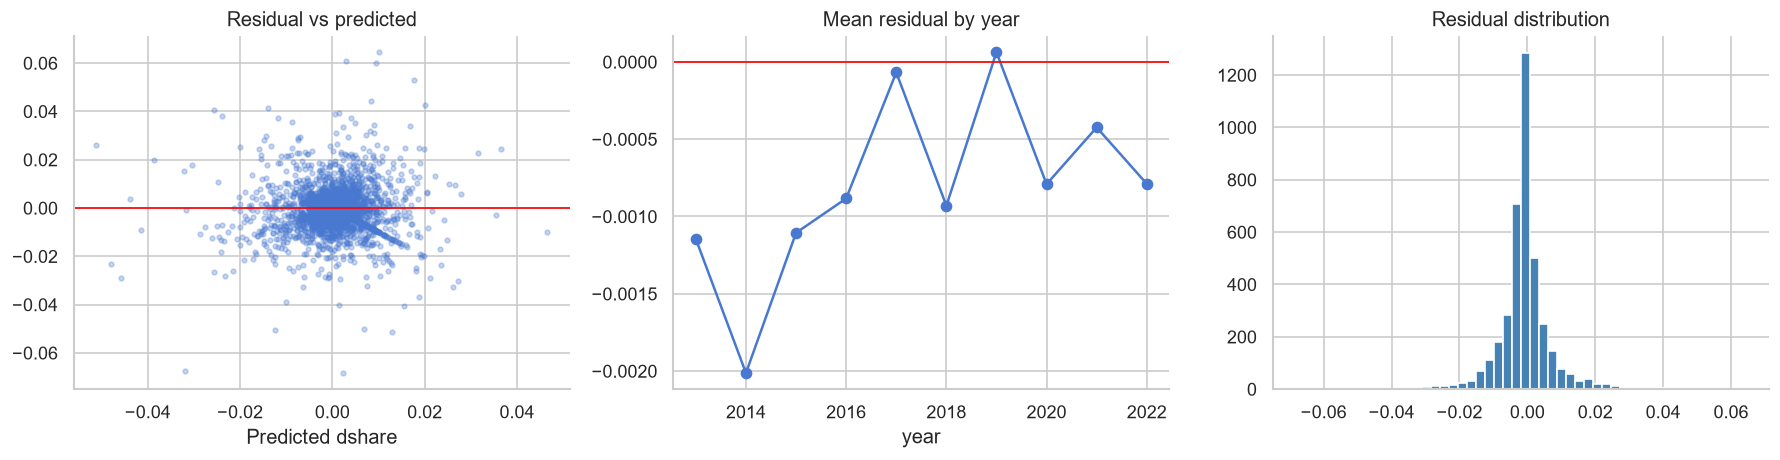

In [46]:
# %% [QA + residual diagnostics]
assert train["year"].max() < SPLIT_YEAR and test["year"].min() >= SPLIT_YEAR
assert SELECT_END < SPLIT_YEAR
assert dm.duplicated(subset=["subject", "word", "year"]).sum() == 0
assert dm["share"].between(0, 1).all() and dm["share_next"].between(0, 1).all()
print("QA pass: split clean, selection precedes test, no dupes, shares in [0,1]")

tc["residual"] = y_te - pred_ridge
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(pred_ridge, tc["residual"], alpha=0.3, s=8)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Predicted dshare"); axes[0].set_title("Residual vs predicted")
tc.groupby("year")["residual"].mean().plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="red", lw=1); axes[1].set_title("Mean residual by year")
axes[2].hist(tc["residual"], bins=50, color="steelblue")
axes[2].set_title("Residual distribution")
sns.despine(); plt.tight_layout(); plt.show()

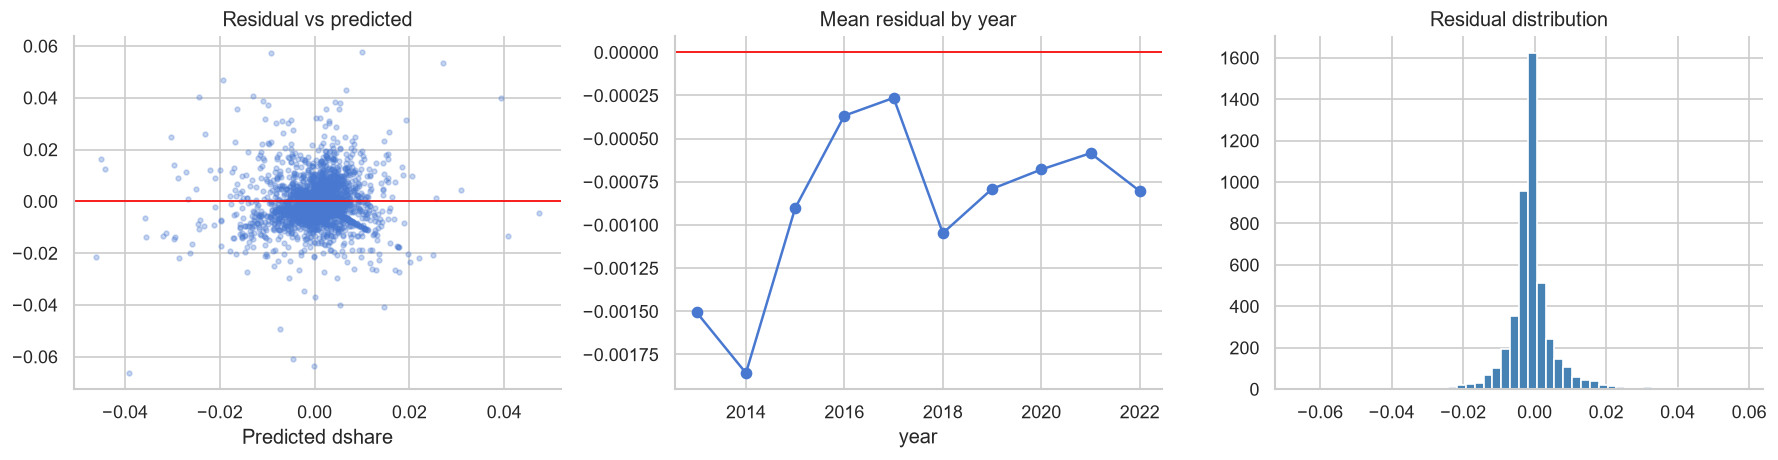

In [47]:
# %% [multi-window experiment -- selection redone inside each window]
def run_window(select_end, split_year, trend_end):
    d = raw[(raw["year"] >= START_YEAR) & (raw["year"] <= trend_end) &
            (raw["total_title_words"] >= MIN_YEAR_WORDS)].copy()
    syt = (d.groupby(["subject", "year"])["total_title_words"]
           .first().rename("total").reset_index())
    p  = select_rising_pairs(d, syt, end_year=select_end)[["subject", "word"]]
    pn = build_feature_panel(d, syt, p)
    dmw = pn.dropna(subset=FEATURES + ["dshare", "total_next"])

    tr, te = dmw[dmw["year"] < split_year], dmw[dmw["year"] >= split_year]
    if len(tr) < 200 or len(te) < 200:
        print(f"{select_end}/{split_year}/{trend_end}: too little data")
        return
    sc = StandardScaler()
    r  = Ridge(alpha=1.0)
    r.fit(sc.fit_transform(tr[FEATURES]), tr["dshare"], sample_weight=tr["total_next"])
    pr = r.predict(sc.transform(te[FEATURES]))
    rmse0 = np.sqrt(mean_squared_error(te["dshare"], np.zeros(len(te))))
    rmse  = np.sqrt(mean_squared_error(te["dshare"], pr))
    nz = (te["dshare"] != 0).values
    da = (np.sign(pr[nz]) == np.sign(te["dshare"].values[nz])).mean()
    print(f"sel<={select_end} split={split_year} end={trend_end} | "
          f"zero-RMSE={rmse0:.6f} ridge-RMSE={rmse:.6f} dir={da:.1%}")

for se, sp, en in [(2004, 2005, 2015), (2007, 2008, 2018),
                   (2009, 2010, 2020), (2012, 2013, 2023)]:
    run_window(se, sp, en)

sel<=2004 split=2005 end=2015 | zero-RMSE=0.008875 ridge-RMSE=0.006847 dir=70.9%
sel<=2007 split=2008 end=2018 | zero-RMSE=0.009761 ridge-RMSE=0.007786 dir=71.7%
sel<=2009 split=2010 end=2020 | zero-RMSE=0.010144 ridge-RMSE=0.008076 dir=69.9%
sel<=2012 split=2013 end=2023 | zero-RMSE=0.010091 ridge-RMSE=0.007989 dir=72.2%


C:\Users\Work\AppData\Local\Temp\ipykernel_13804\2769005277.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  counts = counts.join(
sel<=2004 split=2005 end=2015 | zero-RMSE=0.007940 ridge-RMSE=0.006302 dir=70.2%
C:\Users\Work\AppData\Local\Temp\ipykernel_13804\2769005277.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  counts = counts.join(
sel<=2007 split=2008 end=2018 | zero-RMSE=0.007897 ridge-RMSE=0.006216 dir=71.5%
C:\Users\Work\AppData\Local\Temp\ipykernel_13804\2769005277.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  counts = counts.join(
sel<=2009 split=2010 end=2020 | zero-RMSE=0.008033 ridge-RMSE=0.006468 dir=71.6%
C:\Users\Work\AppData\Local\Temp\ipykernel_13804\2769005277.py:29: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  counts = counts.join(
sel<=2012 split=2013 end=2023 | zero-RMSE=0.008796 ridge-RMSE=0.006950 dir=71.5%

In [48]:
# %% [watchlist for TREND_END + 1 -- full data allowed here (deployment)]
rising_now = select_rising_pairs(df, subj_year_tot, end_year=TREND_END)
pairs_now  = rising_now[["subject", "word"]].drop_duplicates()

panel_now = build_feature_panel(df, subj_year_tot, pairs_now)
latest = panel_now[panel_now["year"] == TREND_END].dropna(subset=FEATURES).copy()

sc_f = StandardScaler()
r_f  = Ridge(alpha=1.0)
r_f.fit(sc_f.fit_transform(dm[FEATURES]), dm["dshare"], sample_weight=dm["total_next"])

latest["pred_dshare"] = r_f.predict(sc_f.transform(latest[FEATURES]))
latest["pred_share"]  = latest["share"] + latest["pred_dshare"]

watch = latest.merge(meta, on="subject")

# only keep words predicted to actually rise
watch_rising = watch[watch["pred_dshare"] > 0].copy()

top5 = (watch_rising.sort_values("pred_dshare", ascending=False)
        .groupby("subject_name").head(5)
        [["subject_name", "word", "share", "pred_share", "pred_dshare",
          "slope_3yr", "spec_cum"]]
        .sort_values(["subject_name", "pred_dshare"], ascending=[True, False])
        .reset_index(drop=True))

# report subjects that had fewer than 5 rising words (list will be shorter there)
counts_per_subj = top5.groupby("subject_name").size()
short = counts_per_subj[counts_per_subj < 5]
if len(short):
    print("Subjects with fewer than 5 predicted rising words:")
    print(short.to_string())

top5.to_csv(f"data/watchlist_{TREND_END + 1}.csv", index=False)
print(f"\nSaved watchlist_{TREND_END + 1}.csv | {len(top5)} words, "
      f"{top5['subject_name'].nunique()} subjects")

# cold-start check
zero_pct = (top5["share"] == 0).mean()
print(f"Words with share==0 at TREND_END (cold-start): {zero_pct:.0%}")

Subjects with fewer than 5 predicted rising words:
subject_name
Algebraic topology                                        3
Approximations and expansions                             1
Associative rings and algebras                            4
Combinatorics                                             3
Commutative rings and algebras                            4
Differential geometry                                     2
Fluid mechanics                                           3
Functional analysis                                       3
Functions of a complex variable                           4
Game theory, economics, social and behavioral sciences    4
Geometry                                                  4
Global analysis, analysis on manifolds                    3
Group theory and generalizations                          3
Linear and multilinear algebra; matrix theory             2
Manifolds and cell complexes                              4
Mathematical logic and foundations  

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>subject_name</th>
      <th>word</th>
      <th>share</th>
      <th>pred_share</th>
      <th>pred_dshare</th>
      <th>slope_3yr</th>
      <th>spec_cum</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Algebraic geometry</td>
      <td>sheaf</td>
      <td>0.005599</td>
      <td>0.009607</td>
      <td>0.004008</td>
      <td>-3.787274e-03</td>
      <td>36.652753</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Algebraic geometry</td>
      <td>moduli_space</td>
      <td>0.004479</td>
      <td>0.005781</td>
      <td>0.001301</td>
      <td>4.432345e-04</td>
      <td>38.226643</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Algebraic geometry</td>
      <td>prym</td>
      <td>0.001120</td>
      <td>0.002026</td>
      <td>0.000906</td>
      <td>-6.376944e-04</td>
      <td>56.320084</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Algebraic geometry</td>
      <td>toric_variety</td>
      <td>0.002240</td>
      <td>0.002716</td>
      <td>0.000477</td>
      <td>-7.778396e-05</td>
      <td>44.672937</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Algebraic geometry</td>
      <td>brill</td>
      <td>0.001120</td>
      <td>0.001278</td>
      <td>0.000158</td>
      <td>-3.889198e-05</td>
      <td>56.192374</td>
    </tr>
    <tr>
      <th>...</th>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
    </tr>
    <tr>
      <th>95</th>
      <td>General</td>
      <td>computational</td>
      <td>0.000000</td>
      <td>0.005993</td>
      <td>0.005993</td>
      <td>-3.703704e-03</td>
      <td>2.133077</td>
    </tr>
    <tr>
      <th>96</th>
      <td>General</td>
      <td>novel</td>
      <td>0.000000</td>
      <td>0.005012</td>
      <td>0.005012</td>
      <td>1.684896e-18</td>
      <td>5.632800</td>
    </tr>
    <tr>
      <th>97</th>
      <td>General</td>
      <td>datum</td>
      <td>0.012821</td>
      <td>0.015590</td>
      <td>0.002770</td>
      <td>-8.404558e-03</td>
      <td>1.501950</td>
    </tr>
    <tr>
      <th>98</th>
      <td>General</td>
      <td>modelling</td>
      <td>0.000000</td>
      <td>0.002364</td>
      <td>0.002364</td>
      <td>-7.407407e-03</td>
      <td>2.920207</td>
    </tr>
    <tr>
      <th>99</th>
      <td>General</td>
      <td>network</td>
      <td>0.012821</td>
      <td>0.010101</td>
      <td>-0.002719</td>
      <td>-9.971510e-04</td>
      <td>2.111480</td>
    </tr>
  </tbody>
</table>
<p>100 rows × 7 columns</p>
</div>

## Reading the results

- Compare Ridge against BOTH baselines. Beating zero-change is easy; beating momentum (`pred = slope_3yr`) is the real test.
- The v1 numbers (RMSE 0.0063 vs baseline 0.0076) are not comparable to these: the target changed (level -> change) and the selection leak is gone. Expect the model-vs-baseline gap to shrink. That is honest, not worse.
- If Ridge does not clearly beat momentum, the next move is features (cross-subject word momentum, subject growth rate), not a bigger model.
- 2024 holdout: rerun with `TREND_END = 2023` watchlist against 2024 data the same way as v1, but keep `SELECT_END < SPLIT_YEAR` for any metric you report.

In [49]:
# %% [correlation check before pruning]
corr_lags = train[["share_lag1", "share_lag2", "share_lag3"]].corr()
corr_mom  = train[["slope_3yr", "slope_5yr", "accel"]].corr()
print("Lag correlations:\n", corr_lags.round(2))
print("\nMomentum correlations:\n", corr_mom.round(2))

Lag correlations:
             share_lag1  share_lag2  share_lag3
share_lag1         1.0        0.70        0.70
share_lag2         0.7        1.00        0.68
share_lag3         0.7        0.68        1.00

Momentum correlations:
            slope_3yr  slope_5yr  accel
slope_3yr       1.00       0.44   0.88
slope_5yr       0.44       1.00  -0.04
accel           0.88      -0.04   1.00


Lag correlations:
             share_lag1  share_lag2  share_lag3
share_lag1        1.00        0.77        0.76
share_lag2        0.77        1.00        0.77
share_lag3        0.76        0.77        1.00

Momentum correlations:
            slope_3yr  slope_5yr  accel
slope_3yr       1.00       0.43   0.89
slope_5yr       0.43       1.00  -0.03
accel           0.89      -0.03   1.00

In [50]:
# %% [feature ablation: try different feature sets]
feature_sets = {
    "full":          FEATURES,
    "no_dead":       [f for f in FEATURES if f not in ["word_age", "spec_cum", "log_volume"]],
    "no_lag3":       [f for f in FEATURES if f != "share_lag3"],
    "no_slope5":     [f for f in FEATURES if f != "slope_5yr"],
    "minimal":       ["share_lag1", "share_lag2", "slope_3yr", "accel"],
}

results = []
for name, feats in feature_sets.items():
    sc = StandardScaler()
    Xtr = sc.fit_transform(train[feats])
    Xte = sc.transform(test[feats])
    r = Ridge(alpha=1.0)
    r.fit(Xtr, y_tr, sample_weight=w_tr)
    pred = r.predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    nz   = y_te != 0
    dir_acc = (np.sign(pred[nz]) == np.sign(y_te[nz])).mean()
    results.append({"feature_set": name, "n_feats": len(feats),
                    "RMSE": rmse, "MAE": mae, "dir_acc": dir_acc})

pd.DataFrame(results).round(6)

,feature_set,n_feats,RMSE,MAE,dir_acc
0,full,4,0.007989,0.004894,0.721761
1,no_dead,4,0.007989,0.004894,0.721761
2,no_lag3,4,0.007989,0.004894,0.721761
3,no_slope5,4,0.007989,0.004894,0.721761
4,minimal,4,0.007989,0.004894,0.721761


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature_set</th>
      <th>n_feats</th>
      <th>RMSE</th>
      <th>MAE</th>
      <th>dir_acc</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>full</td>
      <td>10</td>
      <td>0.006950</td>
      <td>0.004272</td>
      <td>0.715299</td>
    </tr>
    <tr>
      <th>1</th>
      <td>no_dead</td>
      <td>7</td>
      <td>0.006926</td>
      <td>0.004136</td>
      <td>0.732614</td>
    </tr>
    <tr>
      <th>2</th>
      <td>no_lag3</td>
      <td>9</td>
      <td>0.006967</td>
      <td>0.004287</td>
      <td>0.714164</td>
    </tr>
    <tr>
      <th>3</th>
      <td>no_slope5</td>
      <td>9</td>
      <td>0.006950</td>
      <td>0.004272</td>
      <td>0.715299</td>
    </tr>
    <tr>
      <th>4</th>
      <td>minimal</td>
      <td>4</td>
      <td>0.006980</td>
      <td>0.004199</td>
      <td>0.734885</td>
    </tr>
  </tbody>
</table>
</div>

In [51]:
# %% [cross-subject word momentum feature]
# global slope of the word's share across ALL subjects, not just this one
word_year_share = (
    df.groupby(["word", "year"])
    .apply(lambda g: g["count"].sum() / g["total_title_words"].sum(), include_groups=False)
    .rename("global_share")
    .reset_index()
)

def word_global_slope(word, end_year, window=3):
    sub = word_year_share[
        (word_year_share["word"] == word) &
        (word_year_share["year"] <= end_year) &
        (word_year_share["year"] > end_year - window)
    ].sort_values("year")
    if len(sub) < window:
        return np.nan
    return np.polyfit(range(len(sub)), sub["global_share"].values, 1)[0]

dm["global_slope_3yr"] = dm.apply(
    lambda r: word_global_slope(r["word"], r["year"]), axis=1)

FEATURES_V2 = FEATURES + ["global_slope_3yr"]
dm2 = dm.dropna(subset=FEATURES_V2 + ["dshare", "total_next"])

train2 = dm2[dm2["year"] <  SPLIT_YEAR]
test2  = dm2[dm2["year"] >= SPLIT_YEAR]

sc = StandardScaler()
Xtr2 = sc.fit_transform(train2[FEATURES_V2])
Xte2 = sc.transform(test2[FEATURES_V2])
r2 = Ridge(alpha=1.0)
r2.fit(Xtr2, train2["dshare"], sample_weight=train2["total_next"])
pred2 = r2.predict(Xte2)

rmse2 = np.sqrt(mean_squared_error(test2["dshare"], pred2))
mae2  = mean_absolute_error(test2["dshare"], pred2)
nz2   = test2["dshare"].values != 0
dir2  = (np.sign(pred2[nz2]) == np.sign(test2["dshare"].values[nz2])).mean()
print(f"With global_slope_3yr: RMSE={rmse2:.6f} MAE={mae2:.6f} dir_acc={dir2:.1%}")
print(f"Baseline (current):    RMSE=0.006950 MAE=0.004272 dir_acc=71.5%")

print(pd.DataFrame({"feature": FEATURES_V2, "coef": r2.coef_})
      .sort_values("coef", key=abs, ascending=False).to_string(index=False))

With global_slope_3yr: RMSE=0.008779 MAE=0.005604 dir_acc=69.7%
Baseline (current):    RMSE=0.006950 MAE=0.004272 dir_acc=71.5%
         feature      coef
       slope_3yr -0.013828
      share_lag2 -0.006616
      share_lag1  0.006153
           accel  0.006053
global_slope_3yr  0.000114


With global_slope_3yr: RMSE=0.007855 MAE=0.005061 dir_acc=69.9%
Baseline (current):    RMSE=0.006950 MAE=0.004272 dir_acc=71.5%
         feature      coef
      share_lag2 -0.007270
      share_lag1  0.005760
       slope_3yr -0.004061
       slope_5yr -0.003575
           accel -0.002662
      share_lag3  0.001925
         vol_5yr -0.001132
        spec_cum -0.000471
        word_age  0.000258
      log_volume -0.000207
global_slope_3yr  0.000012

In [52]:
# %% [ElasticNet: L1+L2, may auto-prune collinear lags]
from sklearn.linear_model import ElasticNetCV

# use the full 10 features; let L1 decide what to keep
sc = StandardScaler()
Xtr = sc.fit_transform(train[FEATURES])
Xte = sc.transform(test[FEATURES])

# CV over l1_ratio and alpha; time-ordered data so no shuffle in CV
en = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    alphas=np.logspace(-5, 0, 30),
    cv=5,
    max_iter=10000,
    random_state=42,
)
en.fit(Xtr, y_tr, sample_weight=w_tr)
pred_en = en.predict(Xte)

rmse_en = np.sqrt(mean_squared_error(y_te, pred_en))
mae_en  = mean_absolute_error(y_te, pred_en)
nz      = y_te != 0
dir_en  = (np.sign(pred_en[nz]) == np.sign(y_te[nz])).mean()

print(f"ElasticNet   RMSE={rmse_en:.6f} MAE={mae_en:.6f} dir_acc={dir_en:.1%}")
print(f"Ridge (min)  RMSE=0.006980 MAE=0.004199 dir_acc=73.5%")
print(f"chosen alpha={en.alpha_:.5f}  l1_ratio={en.l1_ratio_}")
print()
print(pd.DataFrame({"feature": FEATURES, "coef": en.coef_})
      .sort_values("coef", key=abs, ascending=False).to_string(index=False))

ElasticNet   RMSE=0.007989 MAE=0.004893 dir_acc=72.2%
Ridge (min)  RMSE=0.006980 MAE=0.004199 dir_acc=73.5%
chosen alpha=0.00001  l1_ratio=0.1

   feature      coef
 slope_3yr -0.010483
share_lag2 -0.004917
share_lag1  0.004522
     accel  0.004485


ElasticNet   RMSE=0.006950 MAE=0.004271 dir_acc=71.5%
Ridge (min)  RMSE=0.006980 MAE=0.004199 dir_acc=73.5%
chosen alpha=0.00001  l1_ratio=0.1

   feature      coef
share_lag2 -0.005429
 slope_3yr -0.005325
share_lag1  0.004309
 slope_5yr -0.001693
share_lag3  0.001463
   vol_5yr -0.001091
  word_age  0.000259
  spec_cum -0.000172
log_volume -0.000170
     accel -0.000000

In [53]:
# %% [Ridge with interaction terms on the minimal feature set]
from sklearn.preprocessing import PolynomialFeatures

BASE = ["share_lag1", "share_lag2", "slope_3yr", "accel"]

# degree=2 with interactions: adds squares and all pairwise products
poly = PolynomialFeatures(degree=2, include_bias=False)
Xtr_p = poly.fit_transform(train[BASE])
Xte_p = poly.transform(test[BASE])

sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr_p)
Xte_s = sc.transform(Xte_p)

r = Ridge(alpha=1.0)
r.fit(Xtr_s, y_tr, sample_weight=w_tr)
pred = r.predict(Xte_s)

rmse = np.sqrt(mean_squared_error(y_te, pred))
mae  = mean_absolute_error(y_te, pred)
nz   = y_te != 0
dir_acc = (np.sign(pred[nz]) == np.sign(y_te[nz])).mean()

print(f"Ridge + interactions  RMSE={rmse:.6f} MAE={mae:.6f} dir_acc={dir_acc:.1%}")
print(f"Ridge (minimal)       RMSE=0.006980 MAE=0.004199 dir_acc=73.5%")
print()
print(pd.DataFrame({"term": poly.get_feature_names_out(BASE), "coef": r.coef_})
      .sort_values("coef", key=abs, ascending=False).to_string(index=False))

Ridge + interactions  RMSE=0.007991 MAE=0.004900 dir_acc=71.3%
Ridge (minimal)       RMSE=0.006980 MAE=0.004199 dir_acc=73.5%

                 term      coef
            slope_3yr -0.010323
      slope_3yr accel  0.004960
                accel  0.004686
           share_lag1  0.004459
           share_lag2 -0.004306
share_lag1 share_lag2  0.003637
          slope_3yr^2 -0.003105
              accel^2 -0.002893
         share_lag2^2 -0.002641
         share_lag1^2 -0.001681
 share_lag2 slope_3yr -0.001220
 share_lag1 slope_3yr  0.000620
     share_lag2 accel  0.000161
     share_lag1 accel -0.000063


Ridge + interactions  RMSE=0.006933 MAE=0.004189 dir_acc=73.3%
Ridge (minimal)       RMSE=0.006980 MAE=0.004199 dir_acc=73.5%

                 term      coef
            slope_3yr -0.010005
share_lag1 share_lag2  0.007832
      slope_3yr accel  0.005507
           share_lag1  0.004928
         share_lag2^2 -0.004586
           share_lag2 -0.004539
                accel  0.004497
         share_lag1^2 -0.004388
              accel^2 -0.003674
          slope_3yr^2 -0.002659
 share_lag1 slope_3yr  0.001885
 share_lag2 slope_3yr -0.001691
     share_lag1 accel -0.000620
     share_lag2 accel  0.000478

Entropy trend: slope=0.00966 per year, p=1.62e-09, R2=0.651
Years used: 1987-2023 (37 years)


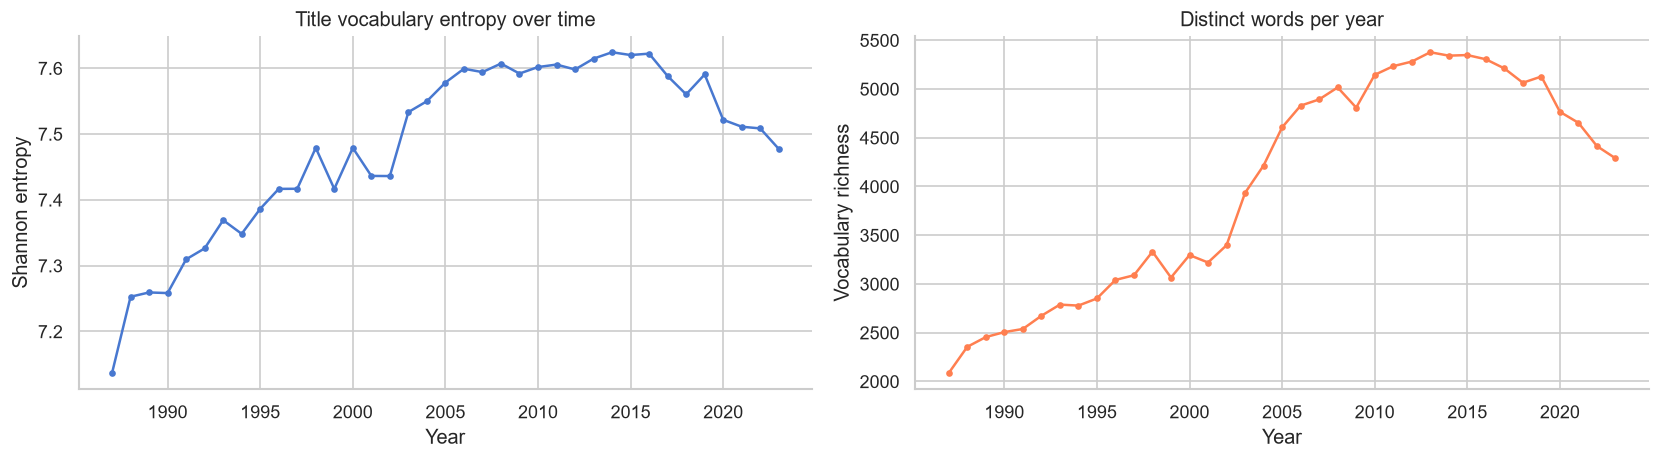

In [54]:
# %% [vocabulary diversity of thesis titles over time]
# Question: is title vocabulary getting more homogeneous or more diverse?
# Metric per year: Shannon entropy of the word-share distribution (all subjects pooled).
# Higher entropy = more diverse vocabulary; falling entropy = homogenizing.

from scipy.stats import linregress

# pooled word counts per year across all subjects
year_word = (
    df.groupby(["year", "word"])["count"].sum()
    .reset_index()
)

def shannon_entropy(counts):
    p = counts / counts.sum()
    return -(p * np.log(p)).sum()

# also track richness (distinct words) and total tokens for context
rows = []
for yr, g in year_word.groupby("year"):
    c = g["count"].values
    rows.append({
        "year": yr,
        "entropy": shannon_entropy(c),
        "n_words": len(c),              # vocabulary richness
        "tokens": int(c.sum()),         # sample size (confounds richness)
    })
div = pd.DataFrame(rows).sort_values("year")

# restrict to well-sampled years to avoid small-sample entropy bias
div_fit = div[div["tokens"] >= 5000]

# trend test on entropy
lr = linregress(div_fit["year"], div_fit["entropy"])
print(f"Entropy trend: slope={lr.slope:.5f} per year, "
      f"p={lr.pvalue:.2e}, R2={lr.rvalue**2:.3f}")
print(f"Years used: {div_fit['year'].min()}-{div_fit['year'].max()} "
      f"({len(div_fit)} years)")

# plot
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(div_fit["year"], div_fit["entropy"], marker="o", ms=3)
ax[0].set_title("Title vocabulary entropy over time")
ax[0].set_xlabel("Year"); ax[0].set_ylabel("Shannon entropy")
ax[1].plot(div_fit["year"], div_fit["n_words"], marker="o", ms=3, color="coral")
ax[1].set_title("Distinct words per year")
ax[1].set_xlabel("Year"); ax[1].set_ylabel("Vocabulary richness")
sns.despine(); plt.tight_layout(); plt.show()

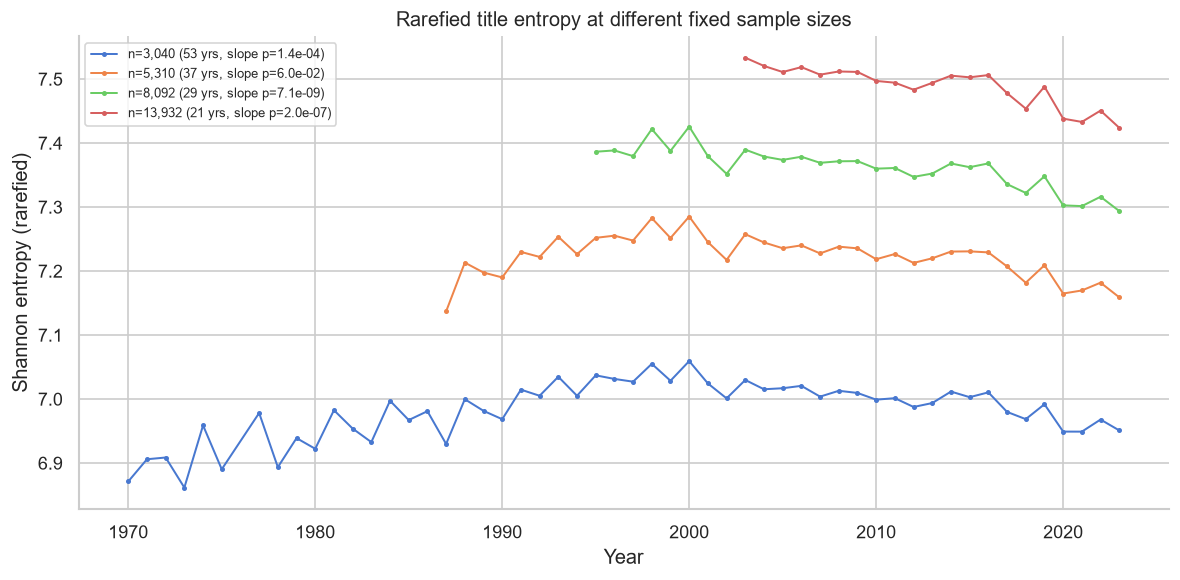

In [56]:
# %% [sensitivity: inverted-U across several fixed-sample sizes]
# Each floor keeps only years with enough tokens, then subsamples all kept
# years down to the smallest among them. Overlaying tests robustness.

from scipy.stats import linregress

rng = np.random.default_rng(42)

# pooled (year, word) counts across all subjects
year_word = df.groupby(["year", "word"])["count"].sum().reset_index()
tokens_per_year = year_word.groupby("year")["count"].sum()

def entropy_of_counts(counts):
    p = counts / counts.sum()
    return -(p * np.log(p)).sum()

def rarefied_entropy(g, n, reps=50):
    # expand (word -> count) into a token pool, draw n without replacement, average over reps
    pool = np.repeat(g["word"].values, g["count"].values.astype(int))
    if len(pool) < n:
        return np.nan
    vals = []
    for _ in range(reps):
        draw = rng.choice(pool, size=n, replace=False)
        _, c = np.unique(draw, return_counts=True)
        vals.append(entropy_of_counts(c))
    return np.mean(vals)

FLOORS = [3000, 5000, 8000, 12000]   # token floors to compare

fig, ax = plt.subplots(figsize=(10, 5))
for floor in FLOORS:
    good = tokens_per_year[tokens_per_year >= floor].index
    if len(good) < 5:
        print(f"floor {floor}: only {len(good)} years, skipped")
        continue
    sample_n = int(tokens_per_year[good].min())

    rows = []
    for yr in good:
        g = year_word[year_word["year"] == yr]
        rows.append({"year": yr, "H": rarefied_entropy(g, sample_n)})
    d = pd.DataFrame(rows).dropna().sort_values("year")

    # trend test for context
    lr = linregress(d["year"], d["H"])
    ax.plot(d["year"], d["H"], marker="o", ms=2, lw=1.2,
            label=f"n={sample_n:,} ({len(d)} yrs, slope p={lr.pvalue:.1e})")

ax.set_title("Rarefied title entropy at different fixed sample sizes")
ax.set_xlabel("Year")
ax.set_ylabel("Shannon entropy (rarefied)")
ax.legend(fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

In [ ]:
# %% [subject vocabulary convergence over time]
# Question: are subjects becoming more similar (shared vocab) or more distinct
# (specialized vocab) over time?
# Metric: for each year, build a subject x word count matrix, cosine-normalize
# rows, compute mean pairwise cosine similarity across subjects. Track over years.

from itertools import combinations
from scipy.stats import linregress
import numpy as np

def mean_pairwise_cosine(year_df):
    # pivot: rows = subject, cols = word, values = count
    mat = year_df.pivot_table(index="subject_code", columns="word",
                               values="count", fill_value=0)
    if mat.shape[0] < 2:
        return np.nan, mat.shape[0]

    # L2-normalize each subject's word vector (so raw volume doesn't dominate)
    norms = np.linalg.norm(mat.values, axis=1, keepdims=True)
    norms[norms == 0] = 1
    normed = mat.values / norms

    sims = []
    for i, j in combinations(range(normed.shape[0]), 2):
        sims.append(normed[i] @ normed[j])
    return np.mean(sims), mat.shape[0]

rows = []
for yr, g in df.groupby("year"):
    sim, n_subj = mean_pairwise_cosine(g)
    rows.append({"year": yr, "mean_cosine": sim, "n_subjects": n_subj})

conv = pd.DataFrame(rows).dropna().sort_values("year")

# keep years with enough subjects present to make the average stable
conv_fit = conv[conv["n_subjects"] >= 5]

lr = linregress(conv_fit["year"], conv_fit["mean_cosine"])
print(f"Convergence trend: slope={lr.slope:+.5f}/yr, p={lr.pvalue:.2e}, R2={lr.rvalue**2:.3f}")
print(f"Years used: {conv_fit['year'].min()}-{conv_fit['year'].max()} ({len(conv_fit)} years)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(conv_fit["year"], conv_fit["mean_cosine"], marker="o", ms=3)
ax.set_title("Mean pairwise subject vocabulary similarity over time")
ax.set_xlabel("Year"); ax.set_ylabel("Mean cosine similarity")
sns.despine(); plt.tight_layout(); plt.show()

KeyError: 'subject_code'

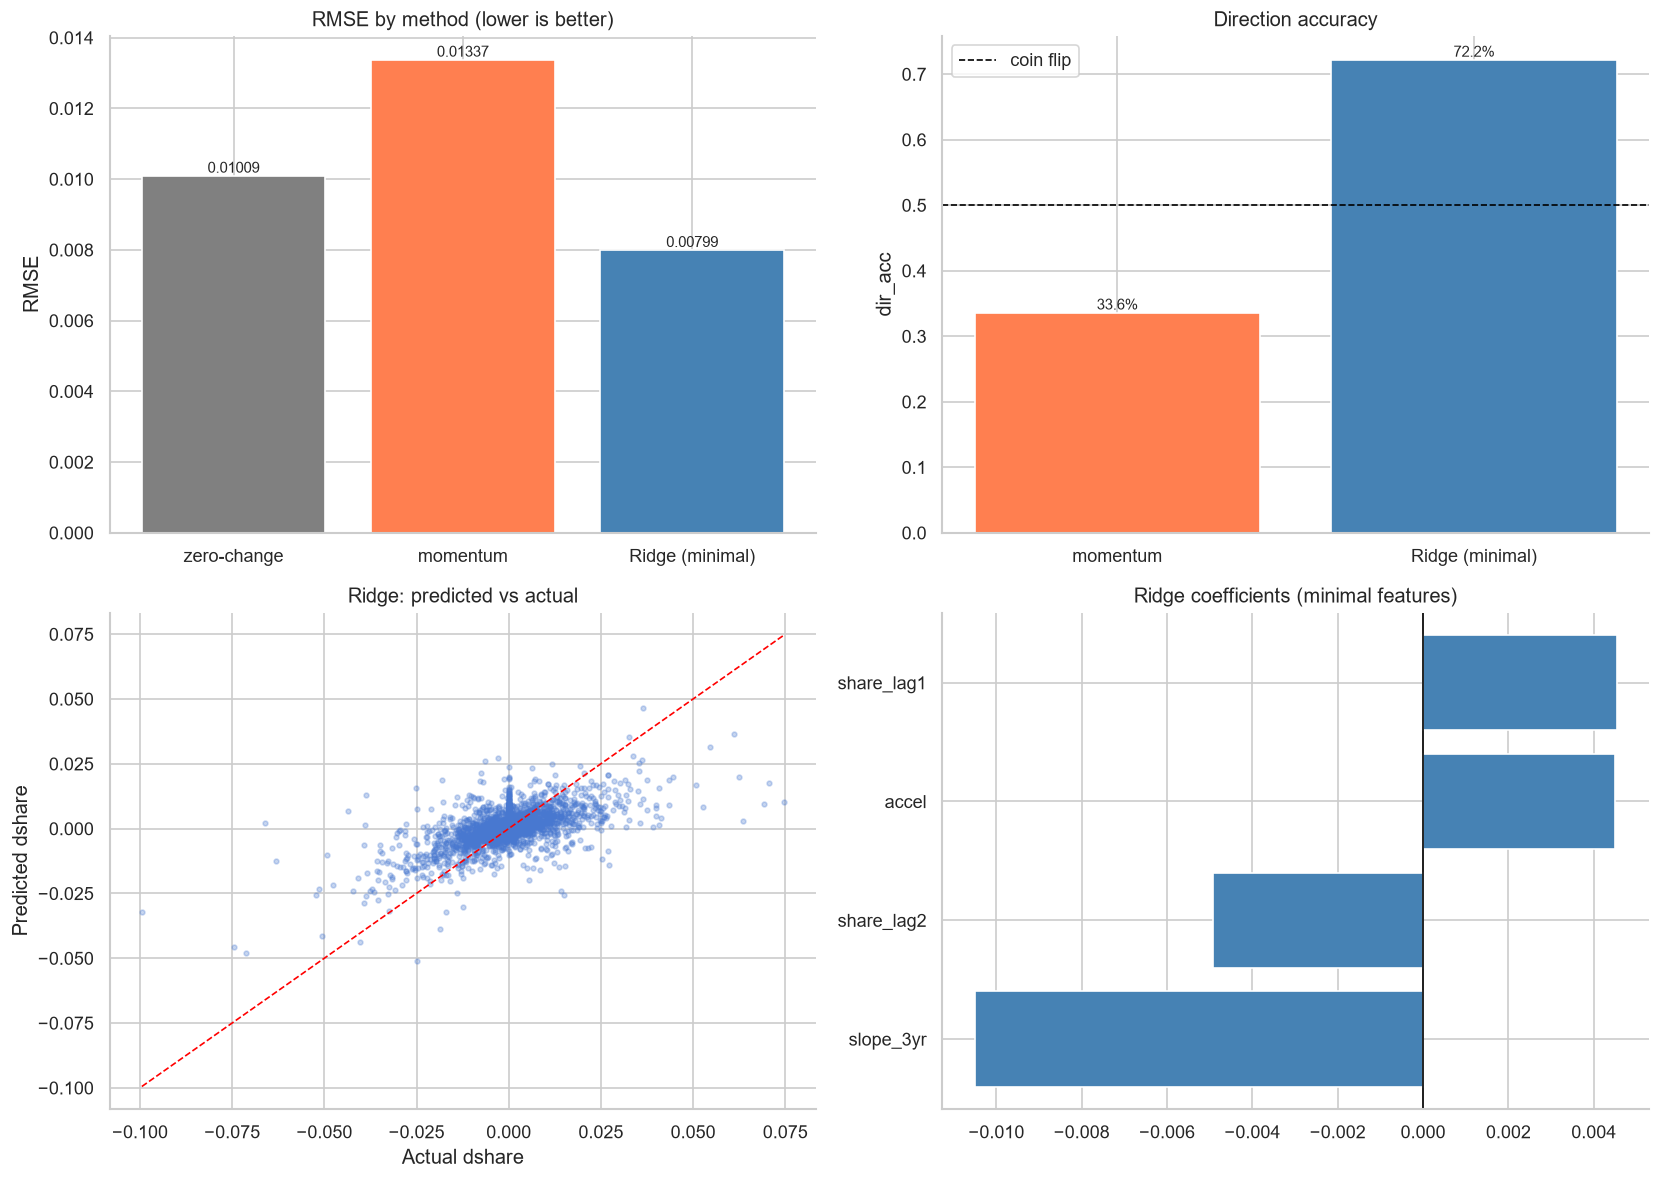

In [24]:
# %% [visualize model results: baselines vs Ridge, ranking, coefficients]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RMSE comparison bar chart
methods = ["zero-change", "momentum", "Ridge (minimal)"]
rmse_vals = [
    np.sqrt(mean_squared_error(y_te, np.zeros(len(y_te)))),
    np.sqrt(mean_squared_error(y_te, test["slope_3yr"].values)),
    np.sqrt(mean_squared_error(y_te, pred_ridge)),
]
axes[0,0].bar(methods, rmse_vals, color=["gray", "coral", "steelblue"])
axes[0,0].set_title("RMSE by method (lower is better)")
axes[0,0].set_ylabel("RMSE")
for i, v in enumerate(rmse_vals):
    axes[0,0].text(i, v, f"{v:.5f}", ha="center", va="bottom", fontsize=9)

# 2. direction accuracy bar chart
dir_vals = [
    np.nan,  # zero-change dir_acc is not meaningful, skip
    (np.sign(test["slope_3yr"].values[y_te != 0]) == np.sign(y_te[y_te != 0])).mean(),
    (np.sign(pred_ridge[y_te != 0]) == np.sign(y_te[y_te != 0])).mean(),
]
axes[0,1].bar(["momentum", "Ridge (minimal)"], dir_vals[1:], color=["coral", "steelblue"])
axes[0,1].axhline(0.5, color="black", ls="--", lw=1, label="coin flip")
axes[0,1].set_title("Direction accuracy")
axes[0,1].set_ylabel("dir_acc")
axes[0,1].legend()
for i, v in enumerate(dir_vals[1:]):
    axes[0,1].text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

# 3. predicted vs actual scatter (Ridge)
axes[1,0].scatter(y_te, pred_ridge, alpha=0.3, s=8)
lims = [min(y_te.min(), pred_ridge.min()), max(y_te.max(), pred_ridge.max())]
axes[1,0].plot(lims, lims, color="red", lw=1, ls="--")
axes[1,0].set_xlabel("Actual dshare")
axes[1,0].set_ylabel("Predicted dshare")
axes[1,0].set_title("Ridge: predicted vs actual")

# 4. Ridge coefficients
coef_df = pd.DataFrame({"feature": FEATURES, "coef": ridge.coef_}).sort_values("coef")
axes[1,1].barh(coef_df["feature"], coef_df["coef"], color="steelblue")
axes[1,1].axvline(0, color="black", lw=1)
axes[1,1].set_title("Ridge coefficients (minimal features)")

sns.despine()
plt.tight_layout()
plt.show()

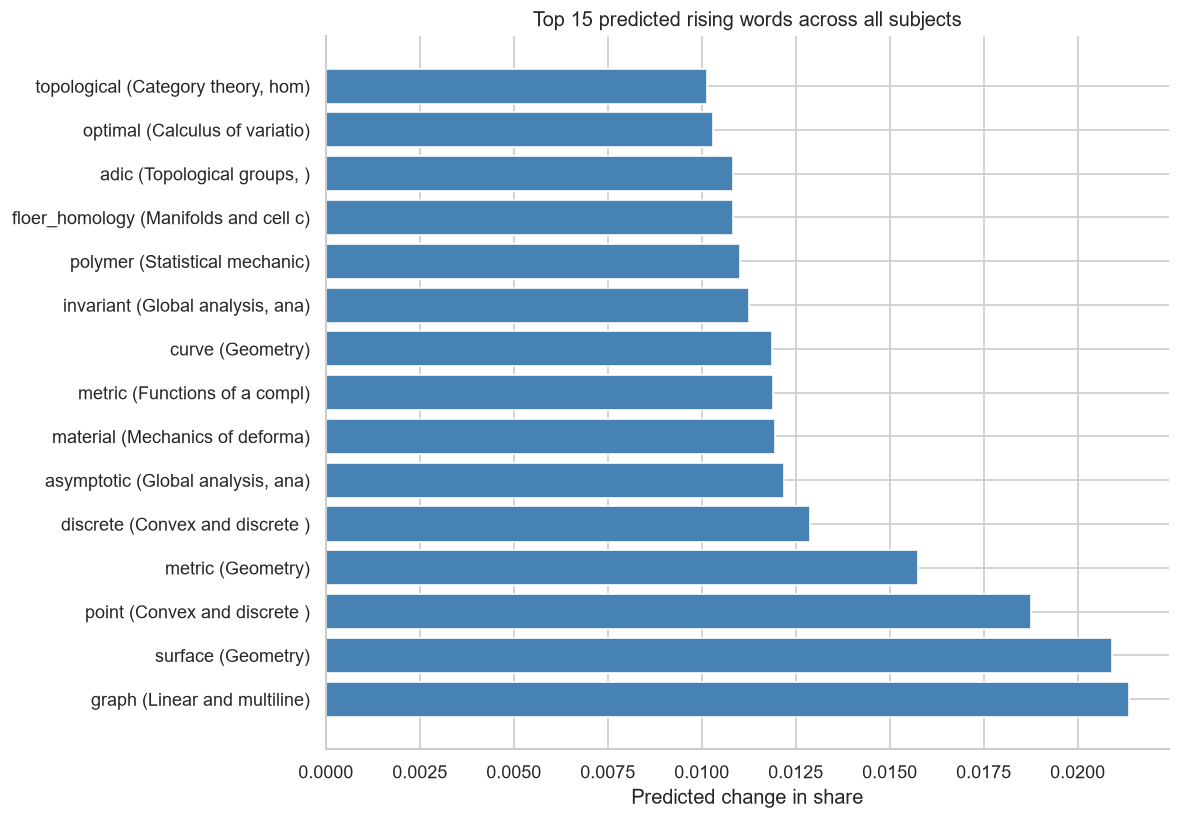

In [28]:
# %% [visualize watchlist: top predicted words per subject]
top_n = top5.nlargest(15, "pred_dshare")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_n["word"] + " (" + top_n["subject_name"].str[:20] + ")",
    top_n["pred_dshare"],
    color="steelblue"
)
ax.set_xlabel("Predicted change in share")
ax.set_title(f"Top 15 predicted rising words across all subjects")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

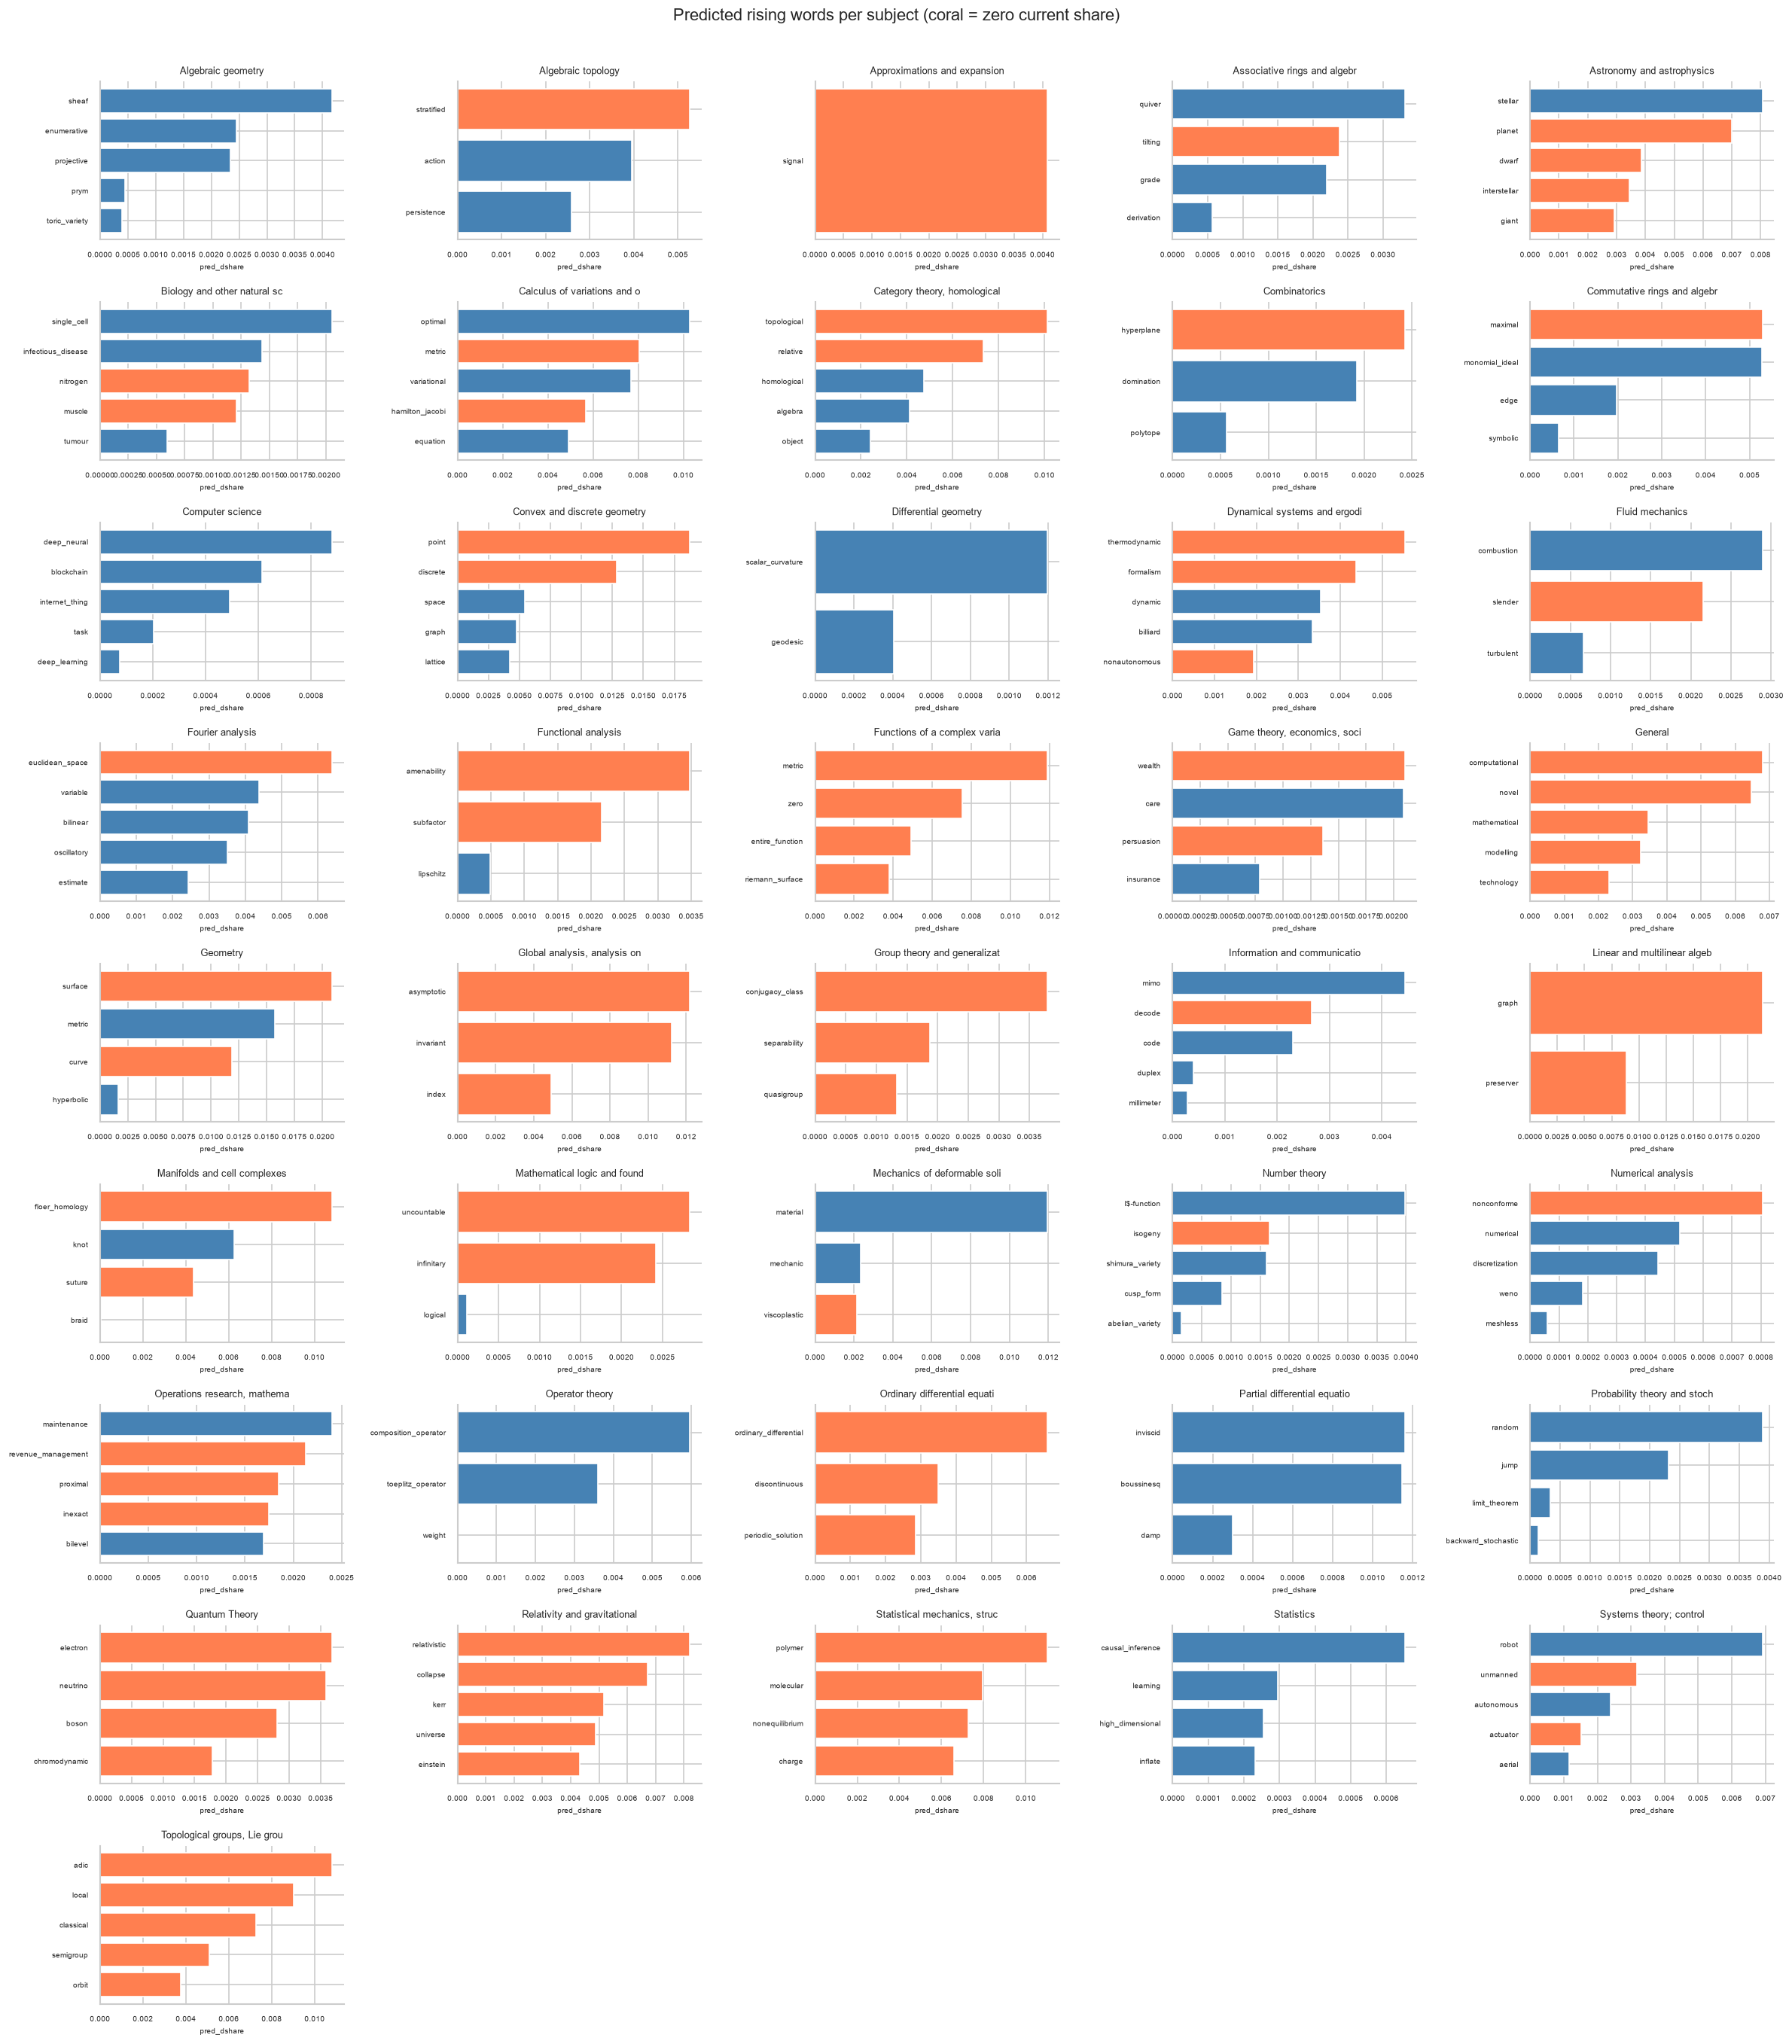

In [29]:
# %% [visualize predicted top words, small multiples per subject]
subjects = top5["subject_name"].unique()
ncols = 5
nrows = -(-len(subjects) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 2.5))
axes = axes.flatten()

for ax, subj in zip(axes, subjects):
    sub = (top5[top5["subject_name"] == subj]
           .sort_values("pred_dshare"))
    colors = ["coral" if s == 0 else "steelblue" for s in sub["share"]]
    ax.barh(sub["word"], sub["pred_dshare"], color=colors)
    ax.set_title(subj[:28], fontsize=8)
    ax.set_xlabel("pred_dshare", fontsize=6)
    ax.tick_params(labelsize=6)
    sns.despine(ax=ax)

for ax in axes[len(subjects):]:
    ax.set_visible(False)

fig.suptitle("Predicted rising words per subject (coral = zero current share)", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

Showing 11 subjects (of 41 total)
                              subject_name  max_pred  cold_start_pct  n
              Convex and discrete geometry  0.018759             0.4  5
Calculus of variations and optimal control  0.010289             0.4  5
      Category theory, homological algebra  0.010129             0.4  5
                   Systems theory; control  0.006911             0.4  5
                          Fourier analysis  0.006393             0.2  5
   Information and communication, circuits  0.004443             0.2  5
                        Algebraic geometry  0.004177             0.0  5
                             Number theory  0.003981             0.2  5
        Biology and other natural sciences  0.002057             0.4  5
                          Computer science  0.000880             0.0  5
                        Numerical analysis  0.000805             0.2  5


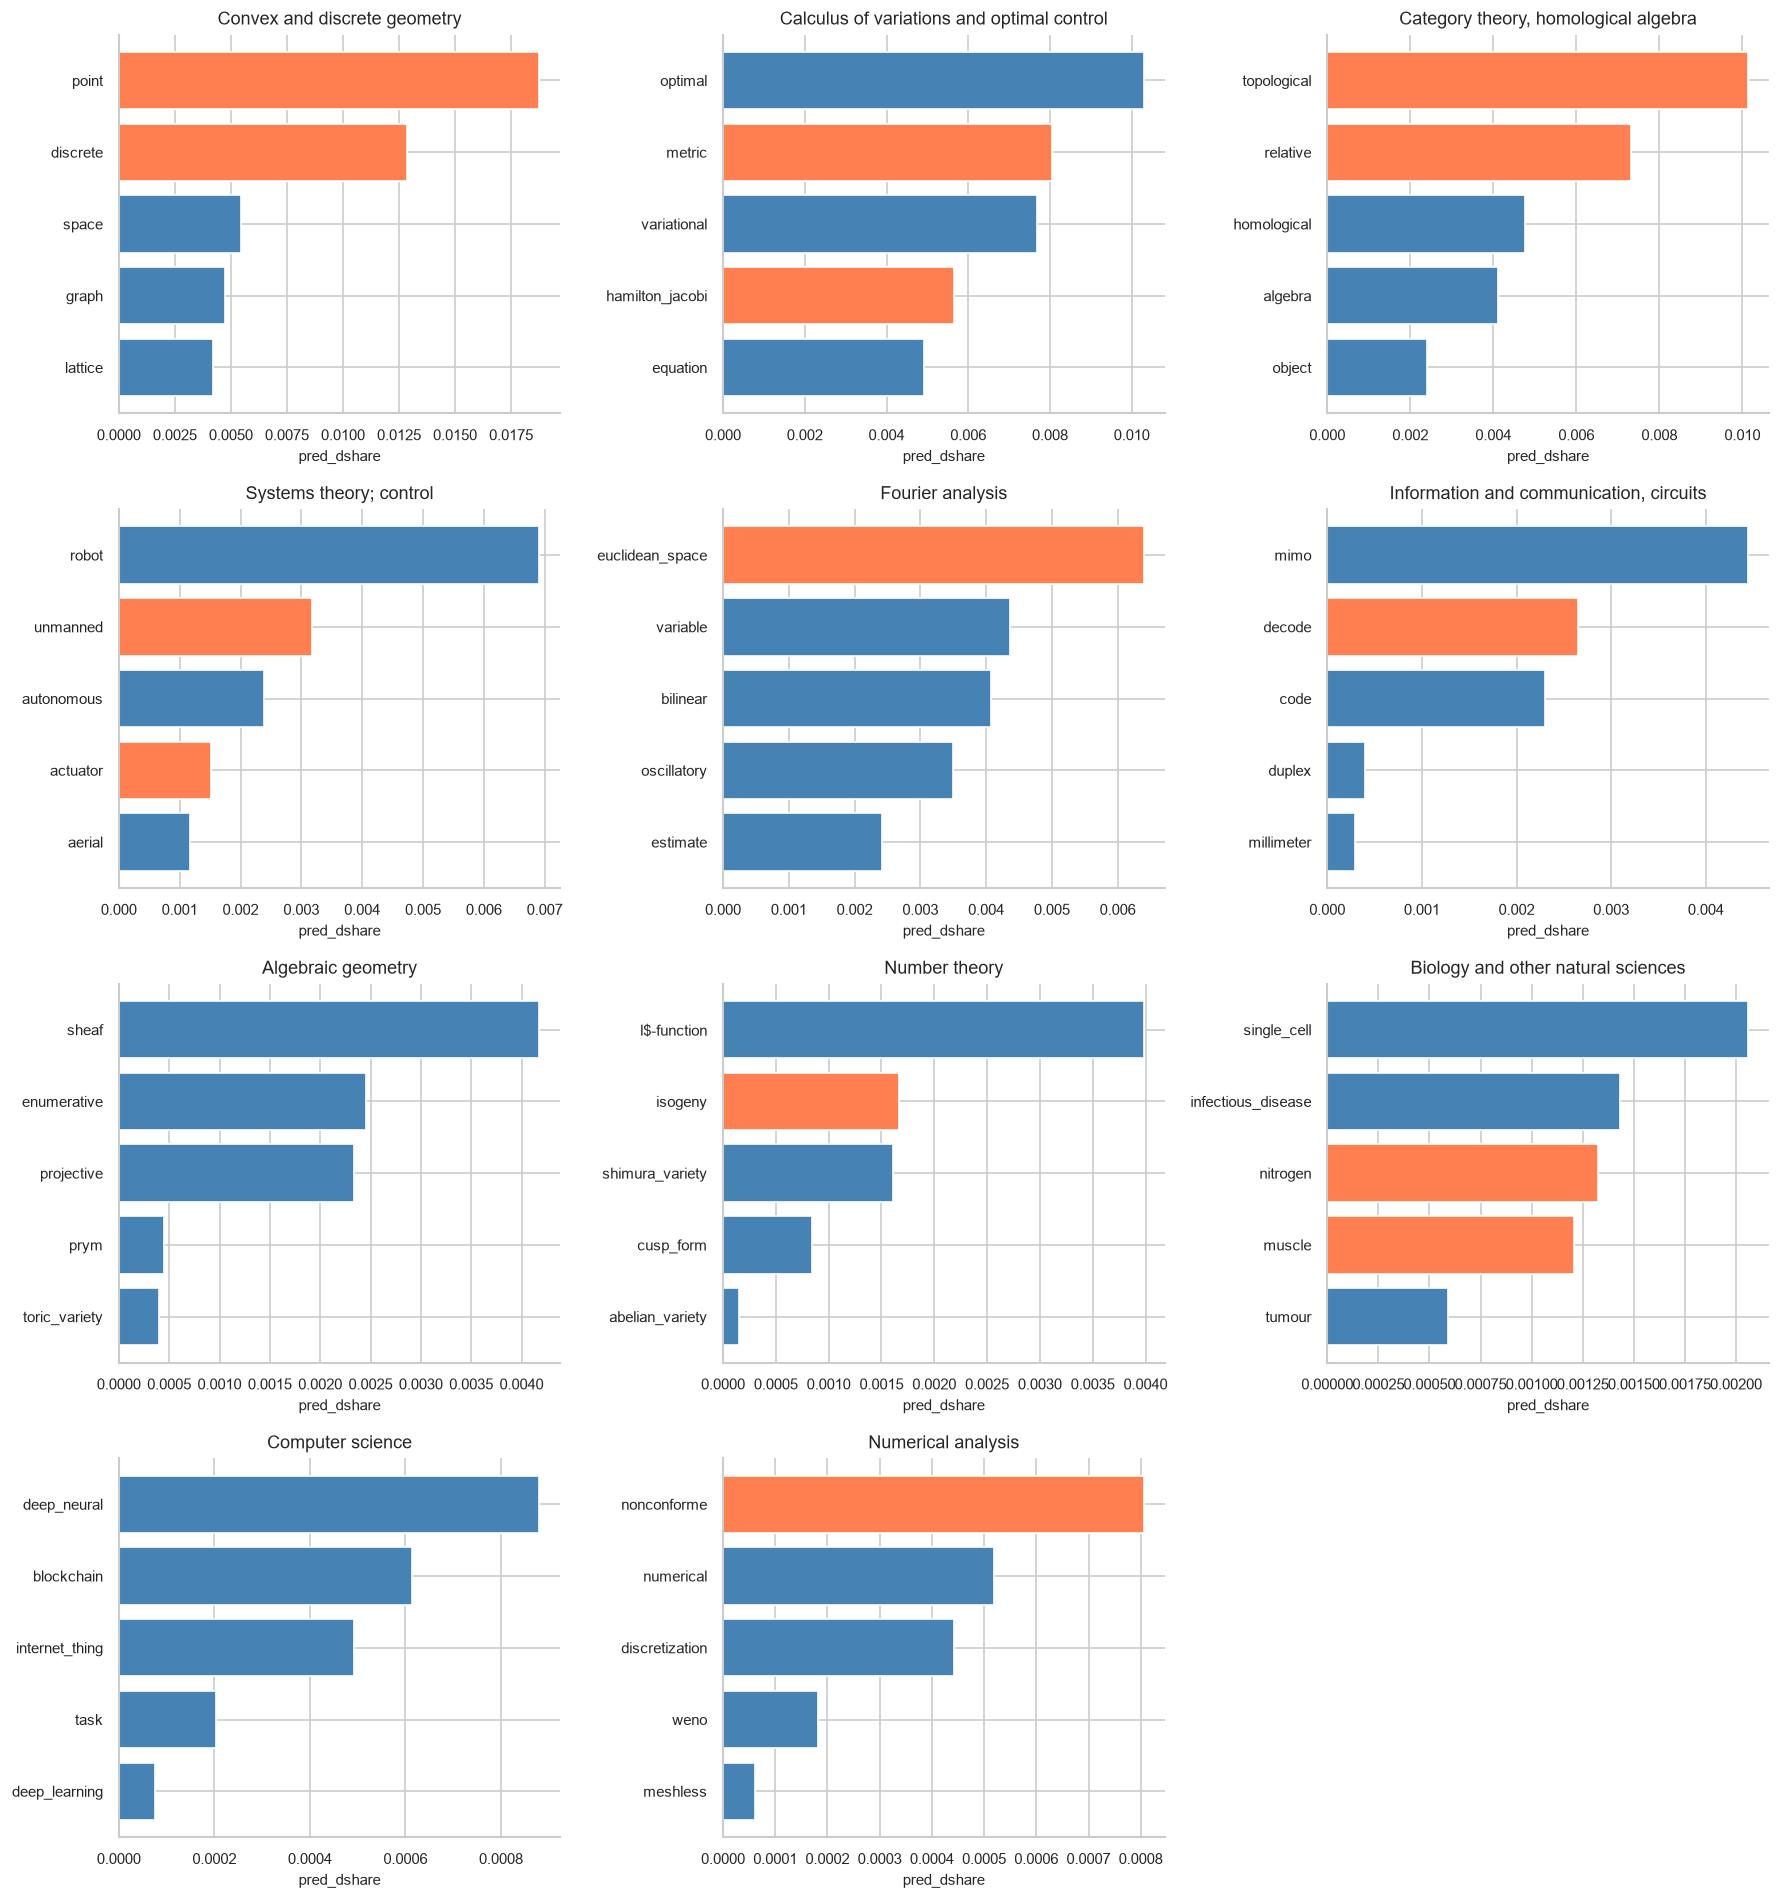

In [31]:
# %% [visualize predicted top words, one image per subject]

subj_quality = (
    top5.groupby("subject_name")
    .agg(max_pred=("pred_dshare", "max"),
         cold_start_pct=("share", lambda s: (s == 0).mean()),
         n=("word", "size"))
    .reset_index()
)

good_subjects = (
    subj_quality[(subj_quality["n"] == 5) & (subj_quality["cold_start_pct"] <= 0.4)]
    .nlargest(15, "max_pred")["subject_name"]
    .tolist()
)

print(f"Showing {len(good_subjects)} subjects (of {top5['subject_name'].nunique()} total)")
print(subj_quality[subj_quality["subject_name"].isin(good_subjects)]
      .sort_values("max_pred", ascending=False).to_string(index=False))

# one figure per subject, 3 per row instead of cramming all into one grid
ncols = 3
nrows = -(-len(good_subjects) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for ax, subj in zip(axes, good_subjects):
    sub = top5[top5["subject_name"] == subj].sort_values("pred_dshare")
    colors = ["coral" if s == 0 else "steelblue" for s in sub["share"]]
    ax.barh(sub["word"], sub["pred_dshare"], color=colors)
    ax.set_title(subj, fontsize=11)
    ax.set_xlabel("pred_dshare", fontsize=9)
    ax.tick_params(labelsize=9)
    sns.despine(ax=ax)

for ax in axes[len(good_subjects):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [32]:
# %% [10-year-ahead target: retrain for decade prediction]
HORIZON = 10

g = panel.groupby(["subject", "word"], sort=False)
panel["share_future"] = g["share"].shift(-HORIZON)
panel["total_future"] = g["total"].shift(-HORIZON)
panel["dshare_10yr"]  = panel["share_future"] - panel["share"]

dm10 = panel.dropna(subset=FEATURES + ["dshare_10yr", "total_future"]).copy()
print(f"Model-ready rows (10yr horizon): {len(dm10):,}")

# split must leave a full 10-year gap so no test-year target peeks past TREND_END
train10 = dm10[dm10["year"] + HORIZON <  SPLIT_YEAR + HORIZON]  # same year cutoff as before
test10  = dm10[dm10["year"] >= SPLIT_YEAR]

X_tr10 = train10[FEATURES].values
y_tr10 = train10["dshare_10yr"].values
w_tr10 = train10["total_future"].values
X_te10 = test10[FEATURES].values
y_te10 = test10["dshare_10yr"].values

sc10 = StandardScaler()
Xtr10_s = sc10.fit_transform(X_tr10)
Xte10_s = sc10.transform(X_te10)

ridge10 = Ridge(alpha=1.0)
ridge10.fit(Xtr10_s, y_tr10, sample_weight=w_tr10)
pred10 = ridge10.predict(Xte10_s)

rmse10 = np.sqrt(mean_squared_error(y_te10, pred10))
mae10  = mean_absolute_error(y_te10, pred10)
nz10   = y_te10 != 0
dir10  = (np.sign(pred10[nz10]) == np.sign(y_te10[nz10])).mean()

# baseline for context: zero-change over 10 years
rmse10_base = np.sqrt(mean_squared_error(y_te10, np.zeros(len(y_te10))))

print(f"10yr zero-change  RMSE={rmse10_base:.6f}")
print(f"10yr Ridge         RMSE={rmse10:.6f}  MAE={mae10:.6f}  dir_acc={dir10:.1%}")

Model-ready rows (10yr horizon): 12,794
10yr zero-change  RMSE=0.010411
10yr Ridge         RMSE=0.008837  MAE=0.005965  dir_acc=61.6%


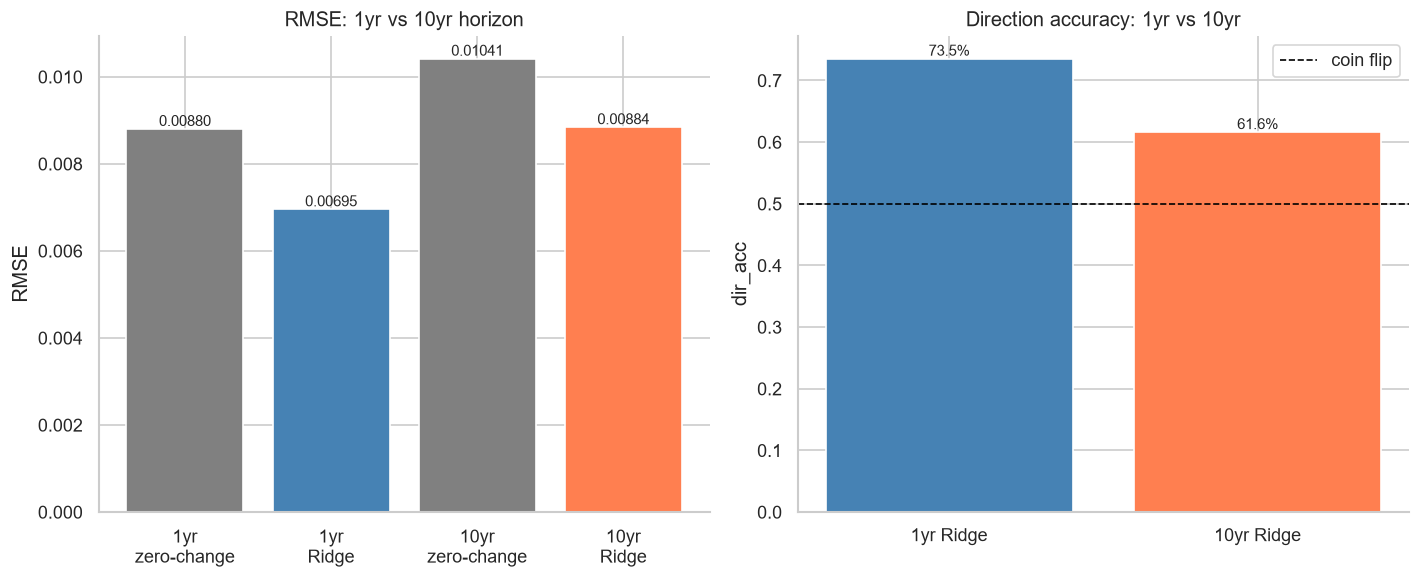

In [33]:
# %% [visualize: 1yr vs 10yr model performance]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RMSE comparison
horizons = ["1yr\nzero-change", "1yr\nRidge", "10yr\nzero-change", "10yr\nRidge"]
rmse_vals = [0.008796, 0.006950, rmse10_base, rmse10]
colors = ["gray", "steelblue", "gray", "coral"]
axes[0].bar(horizons, rmse_vals, color=colors)
axes[0].set_title("RMSE: 1yr vs 10yr horizon")
axes[0].set_ylabel("RMSE")
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v, f"{v:.5f}", ha="center", va="bottom", fontsize=9)

# dir_acc comparison
dir_vals = [0.735, dir10]
axes[1].bar(["1yr Ridge", "10yr Ridge"], dir_vals, color=["steelblue", "coral"])
axes[1].axhline(0.5, color="black", ls="--", lw=1, label="coin flip")
axes[1].set_title("Direction accuracy: 1yr vs 10yr")
axes[1].set_ylabel("dir_acc")
axes[1].legend()
for i, v in enumerate(dir_vals):
    axes[1].text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()